# Площадь под графиком и управление порогом

In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X, y = make_classification(n_samples=1000, n_classes=2, random_state=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=2)
model = LogisticRegression().fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)
y_pred_proba

array([[4.02958497e-03, 9.95970415e-01],
       [2.00643855e-03, 9.97993561e-01],
       [9.94696564e-01, 5.30343592e-03],
       [8.47909962e-01, 1.52090038e-01],
       [1.66614096e-03, 9.98333859e-01],
       [4.99240075e-01, 5.00759925e-01],
       [9.80208762e-01, 1.97912375e-02],
       [9.76507391e-01, 2.34926092e-02],
       [1.79866697e-02, 9.82013330e-01],
       [2.93132539e-01, 7.06867461e-01],
       [9.95836132e-01, 4.16386810e-03],
       [2.53456369e-01, 7.46543631e-01],
       [9.92314475e-01, 7.68552501e-03],
       [3.80237693e-02, 9.61976231e-01],
       [6.47256719e-02, 9.35274328e-01],
       [1.91873737e-01, 8.08126263e-01],
       [8.55142720e-01, 1.44857280e-01],
       [4.34150814e-02, 9.56584919e-01],
       [8.43060465e-01, 1.56939535e-01],
       [5.51009943e-02, 9.44899006e-01],
       [1.32996996e-01, 8.67003004e-01],
       [5.89343759e-01, 4.10656241e-01],
       [9.79492824e-01, 2.05071761e-02],
       [3.32717535e-01, 6.67282465e-01],
       [9.957351

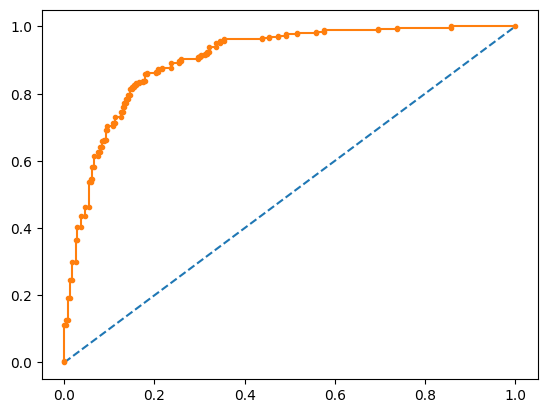

In [135]:
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])

plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr, tpr, marker='.')
plt.show()

In [136]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_pred_proba[:, 1])

0.9027724358974359

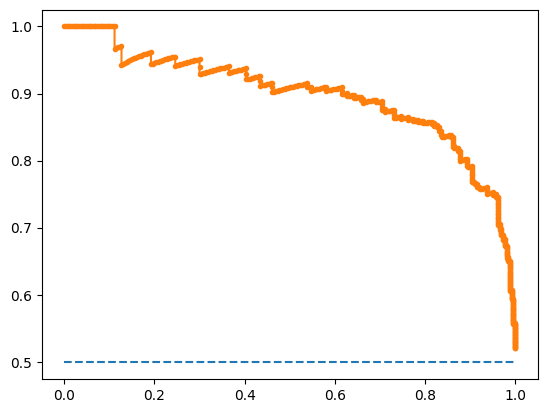

In [137]:
from sklearn.metrics import precision_recall_curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba[:, 1])

no_skill = len(y[y==1]) / len(y)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--')
plt.plot(recall, precision, marker='.')
plt.show()

In [138]:
from sklearn.metrics import auc
auc(recall, precision)

0.897662372903334

In [139]:
from sklearn.metrics import classification_report
y_test_pred = model.predict(X_test)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.83      0.82      0.83       240
           1       0.84      0.85      0.84       260

    accuracy                           0.83       500
   macro avg       0.83      0.83      0.83       500
weighted avg       0.83      0.83      0.83       500



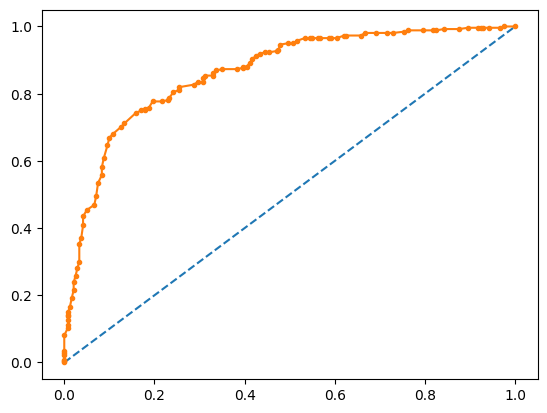

In [140]:
from sklearn.neighbors import KNeighborsClassifier
model2 = KNeighborsClassifier(n_neighbors=250).fit(X_train, y_train)
y_pred2_proba = model2.predict_proba(X_test)
fpr, tpr, _ = roc_curve(y_test, y_pred2_proba[:, 1])

plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr, tpr, marker='.')
plt.show()

In [141]:
roc_auc_score(y_test, y_pred2_proba[:, 1])

0.8630608974358974

In [142]:
X, y = make_classification(n_samples=1000, n_classes=2, weights=[0.99, 0.01], random_state=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=4)

print('Датасет: Class0=%d, Class1=%d' % (len(y[y==0]), len(y[y==1])))
print('Обучающая: Class0=%d, Class1=%d' % (len(y_train[y_train==0]), len(y_train[y_train==1])))
print('Тестовая: Class0=%d, Class1=%d' % (len(y_test[y_test==0]), len(y_test[y_test==1])))

Датасет: Class0=985, Class1=15
Обучающая: Class0=490, Class1=10
Тестовая: Class0=495, Class1=5


In [143]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y)
model = LogisticRegression().fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)
model = LogisticRegression().fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)
y_test_pred = model.predict(X_test)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       492
           1       0.00      0.00      0.00         8

    accuracy                           0.98       500
   macro avg       0.49      0.50      0.50       500
weighted avg       0.97      0.98      0.98       500



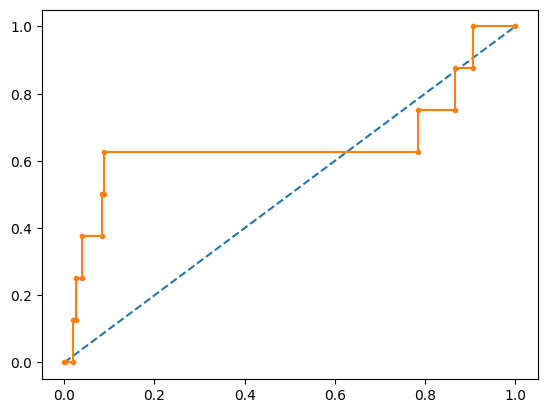

In [144]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])

plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr, tpr, marker='.')
plt.show()

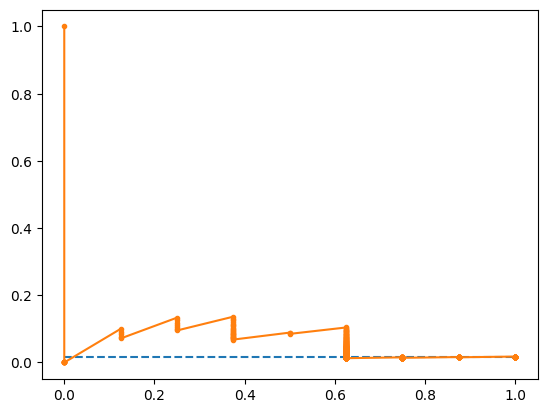

In [145]:
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba[:, 1])
no_skill = len(y[y==1]) / len(y)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--')
plt.plot(recall, precision, marker='.')
plt.show()

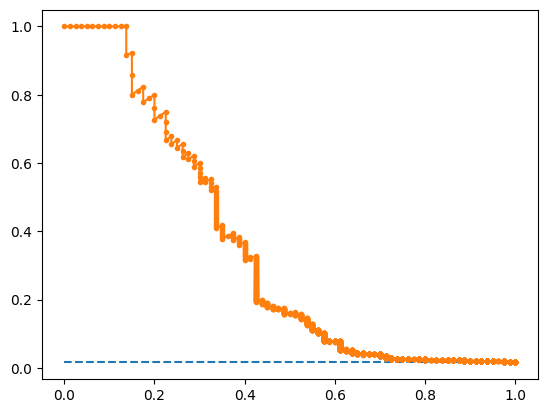

In [146]:
X, y = make_classification(n_samples=10000, n_classes=2, weights=[0.99, 0.01], random_state=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y)

model = LogisticRegression().fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)

p, r, pr_thresholds = precision_recall_curve(y_test, y_pred_proba[:, 1])
no_skill = len(y[y==1]) / len(y)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--')
plt.plot(r, p, marker='.')
plt.show()

In [147]:
from numpy import argmax
f1 = (2 * p * r) / (p + r)
ix = argmax(f1)
print('Порог=%f, F-Score=%.3f' % (pr_thresholds[ix], f1[ix]))

Порог=0.183777, F-Score=0.412


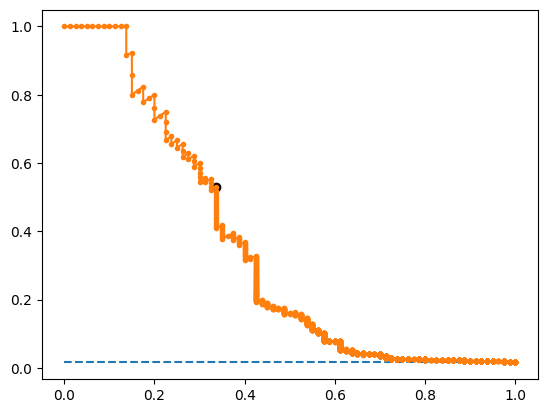

In [148]:
plt.plot([0, 1], [no_skill, no_skill], linestyle='--')
plt.plot(r, p, marker='.')
plt.scatter(r[ix], p[ix], marker='o', color='black')
plt.show()

In [149]:
y_pred = (y_pred_proba[:, 1] > pr_thresholds[ix]).astype('int')
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4920
           1       0.52      0.33      0.40        80

    accuracy                           0.98      5000
   macro avg       0.75      0.66      0.70      5000
weighted avg       0.98      0.98      0.98      5000



In [150]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4920
           1       0.81      0.16      0.27        80

    accuracy                           0.99      5000
   macro avg       0.90      0.58      0.63      5000
weighted avg       0.98      0.99      0.98      5000



## Задания для самостоятельного выполнения

#### 1. Повторите анализ из лабораторной работы, но с двумерными датасетами. Изобразите графически, как изменение порога влияет на расположение границы принятия решений.

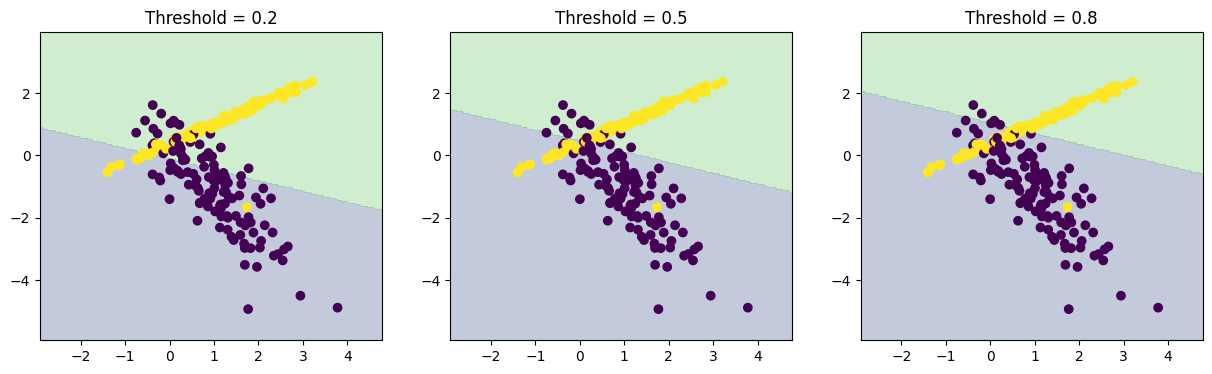

In [151]:
X, y = make_classification(n_samples=500, n_features=2, n_redundant=0,
                           n_clusters_per_class=1, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)
model = LogisticRegression().fit(X_train, y_train)

x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

grid = np.c_[xx.ravel(), yy.ravel()]
proba = model.predict_proba(grid)[:, 1]

thresholds = [0.2, 0.5, 0.8]
plt.figure(figsize=(15, 4))

for i, t in enumerate(thresholds):
    plt.subplot(1, 3, i+1)
    Z = (proba > t).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test)
    plt.title(f"Threshold = {t}")

plt.show()

#### 2. Повторите анализ на реальном датасете для бинарной классификации. Проинтерпретируйте результат, сделайте вывод.

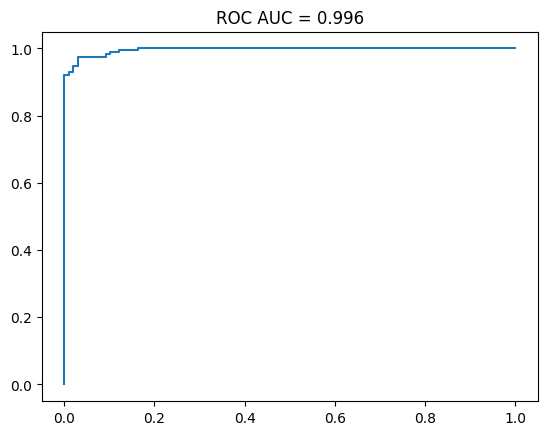

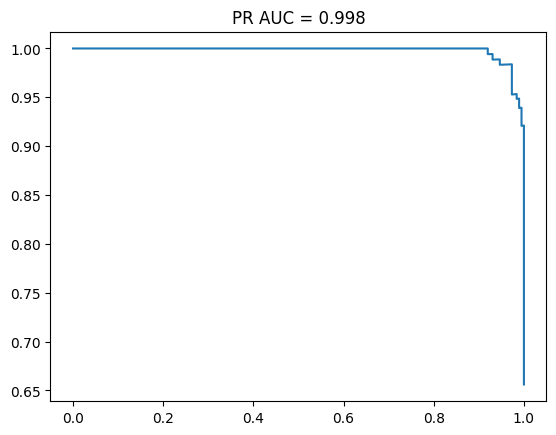

In [152]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

model = LogisticRegression(max_iter=5000).fit(X_train, y_train)
y_proba = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)

plt.plot(fpr, tpr)
plt.title(f"ROC AUC = {roc_auc:.3f}")
plt.show()

plt.plot(recall, precision)
plt.title(f"PR AUC = {pr_auc:.3f}")
plt.show()

#### для датасета breast cancer модель логистической регрессии показывает высокие значения ROC-AUC и PR-AUC, что говорит о хорошем разделении классов. PR-кривая дополнительно подтверждает стабильность качества для положительного класса, поэтому модель можно считать подходящей для этой задачи.

#### 3. В задании по оптимизации порога используйте ROC и среднее геометрическое между TPR и FPR как критерий оптимизации.

Best Threshold: 0.45980595261676815
Best G-Mean: 0.9713229619490485


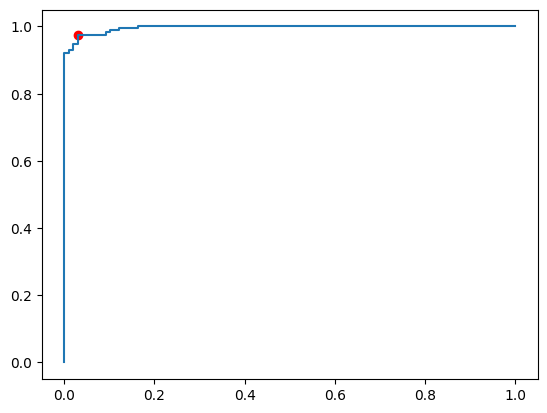

In [153]:
from numpy import sqrt

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
gmean = sqrt(tpr * (1 - fpr))
ix = argmax(gmean)
print("Best Threshold:", thresholds[ix])
print("Best G-Mean:", gmean[ix])

plt.plot(fpr, tpr)
plt.scatter(fpr[ix], tpr[ix], color='red')
plt.show()

#### 4. При оптимизации порога по PR-кривой используйте другую F-метрику - сначала с преимуществом precision, а затем - с превалированием recall. Изобразите получившиеся пороги на графике. Проанализируйте метрики получившихся моделей.

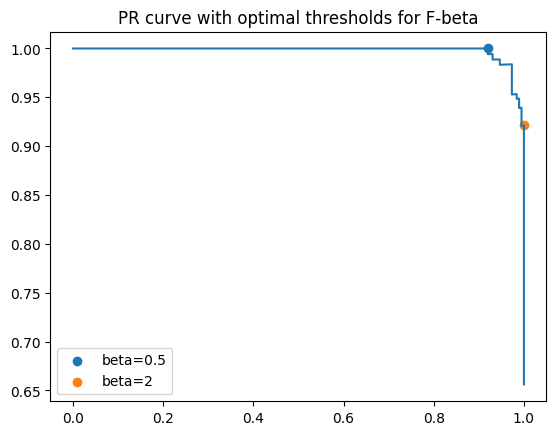

Threshold beta=0.5: 0.7804416464893916
Threshold beta=2: 0.029095112112543394

default threshold (0.5)
              precision    recall  f1-score   support

           0       0.92      0.97      0.95        98
           1       0.98      0.96      0.97       187

    accuracy                           0.96       285
   macro avg       0.95      0.96      0.96       285
weighted avg       0.96      0.96      0.96       285

beta=0.5 (precision-oriented)
              precision    recall  f1-score   support

           0       0.87      1.00      0.93        98
           1       1.00      0.92      0.96       187

    accuracy                           0.95       285
   macro avg       0.93      0.96      0.94       285
weighted avg       0.95      0.95      0.95       285

beta=2 (recall-oriented)
              precision    recall  f1-score   support

           0       1.00      0.84      0.91        98
           1       0.92      1.00      0.96       187

    accuracy            

In [154]:
from sklearn.datasets import load_breast_cancer

def fbeta(p, r, beta):
    return (1 + beta**2) * (p * r) / (beta**2 * p + r + 1e-9)

data = load_breast_cancer()
X_local, y_local = data.data, data.target
X_train_local, X_test_local, y_train_local, y_test_local = train_test_split(
    X_local, y_local, test_size=0.5, random_state=42
)
model_local = LogisticRegression(max_iter=5000).fit(X_train_local, y_train_local)
y_proba_local = model_local.predict_proba(X_test_local)[:, 1]

p, r, thresholds = precision_recall_curve(y_test_local, y_proba_local)
p_thr = p[:-1]
r_thr = r[:-1]

f_beta_low = fbeta(p_thr, r_thr, beta=0.5)
ix_low = argmax(f_beta_low)
f_beta_high = fbeta(p_thr, r_thr, beta=2)
ix_high = argmax(f_beta_high)

plt.plot(r, p)
plt.scatter(r_thr[ix_low], p_thr[ix_low], label="beta=0.5")
plt.scatter(r_thr[ix_high], p_thr[ix_high], label="beta=2")
plt.legend()
plt.title("PR curve with optimal thresholds for F-beta")
plt.show()

thr_low = thresholds[ix_low]
thr_high = thresholds[ix_high]
print("Threshold beta=0.5:", thr_low)
print("Threshold beta=2:", thr_high)

y_pred_low = (y_proba_local >= thr_low).astype(int)
y_pred_high = (y_proba_local >= thr_high).astype(int)
y_pred_default = (y_proba_local >= 0.5).astype(int)
print("\ndefault threshold (0.5)")
print(classification_report(y_test_local, y_pred_default))
print("beta=0.5 (precision-oriented)")
print(classification_report(y_test_local, y_pred_low))
print("beta=2 (recall-oriented)")
print(classification_report(y_test_local, y_pred_high))

#### 5. Постройте классификационные кривые для задачи множественной классификации. Проинтерпретируйте результат.

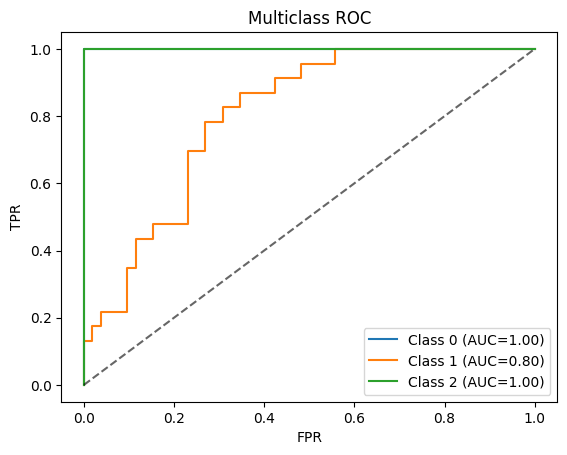

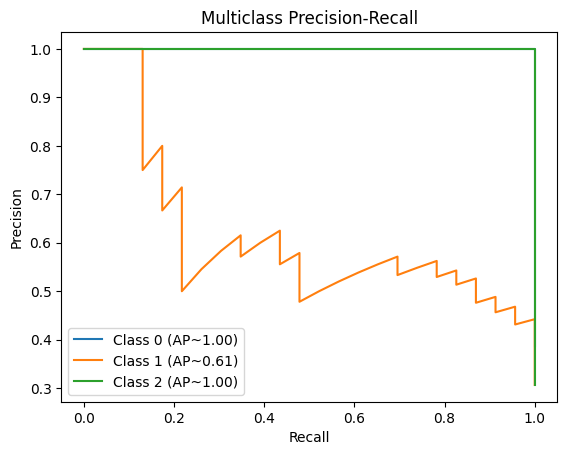

In [155]:
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.datasets import load_iris

data = load_iris()
X = data.data
y = data.target

y_bin = label_binarize(y, classes=[0, 1, 2])

X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.5, random_state=42
)

model = OneVsRestClassifier(LogisticRegression(max_iter=5000))
model.fit(X_train, y_train)
y_score = model.predict_proba(X_test)

# Multiclass ROC curves
plt.figure()
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_score[:, i])
    roc_auc_i = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc_i:.2f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.6)
plt.legend()
plt.title("Multiclass ROC")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

# Multiclass PR curves
plt.figure()
for i in range(3):
    precision_i, recall_i, _ = precision_recall_curve(y_test[:, i], y_score[:, i])
    pr_auc_i = auc(recall_i, precision_i)
    plt.plot(recall_i, precision_i, label=f"Class {i} (AP~{pr_auc_i:.2f})")
plt.legend()
plt.title("Multiclass Precision-Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

#### на графиках для всех классов кривые расположены существенно выше базовых линий, что указывает на хорошее качество one-vs-rest классификации. Различия между кривыми классов показывают, что классы имеют разную сложность разделения, но в целом модель корректно решает задачу множественной классификации.

#### 6. Используйте для построения кривых библиотеку yellowbrick.

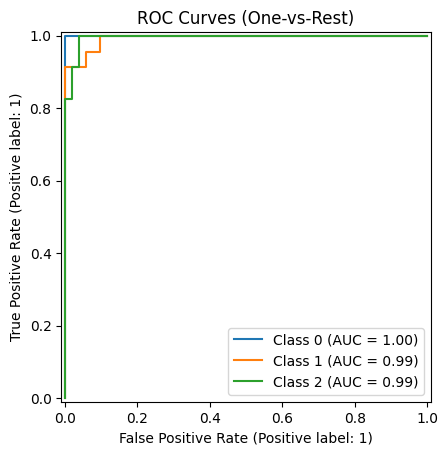

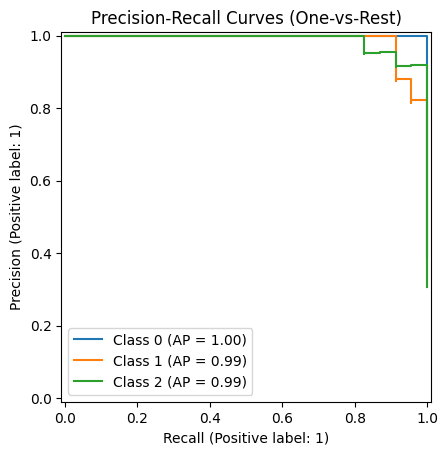

In [156]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

y_train_labels = y_train.argmax(axis=1)
y_test_labels = y_test.argmax(axis=1)
classes = np.unique(y_train_labels)

clf = OneVsRestClassifier(LogisticRegression(max_iter=5000))
clf.fit(X_train, y_train_labels)
y_score = clf.predict_proba(X_test)
y_test_bin = label_binarize(y_test_labels, classes=classes)

fig, ax = plt.subplots()
for i, class_id in enumerate(classes):
    RocCurveDisplay.from_predictions(
        y_test_bin[:, i], y_score[:, i], name=f"Class {class_id}", ax=ax
    )
ax.set_title("ROC Curves (One-vs-Rest)")
plt.show()

fig, ax = plt.subplots()
for i, class_id in enumerate(classes):
    PrecisionRecallDisplay.from_predictions(
        y_test_bin[:, i], y_score[:, i], name=f"Class {class_id}", ax=ax
    )
ax.set_title("Precision-Recall Curves (One-vs-Rest)")
plt.show()